In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    DataCollatorForLanguageModeling,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'✓ Setup complete | Device: {device}')

✓ Setup complete | Device: cpu


In [ ]:
df = pd.read_csv('/content/swahiliproverbs.csv')
df = df[['swahili_proverb', 'label']].dropna().copy()
df['swahili_proverb'] = df['swahili_proverb'].astype(str).str.strip()
df['label']           = df['label'].astype(str).str.strip()
df = df[df['swahili_proverb'] != ''].reset_index(drop=True)

print(f'✓ Loaded: {len(df)} proverbs, {df["label"].nunique()} categories')
df.head(5)

✓ Loaded: 5060 proverbs, 56 categories


,swahili_proverb,label
0,Achekaye kilema hata kwao kipo.,Abuse
1,Afadhali lawama ya wazi.,Abuse
2,Afanyae mzaha na watu humlazimu awe na saburi.,Abuse
3,Ajabu ya kondoo kucheka kioo.,Abuse
4,Ajabu ya ngamia kucheka nundu ya ng'ombe.,Abuse


In [ ]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])
x  = df['swahili_proverb'].values
num_classes = len(le.classes_)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train
)

print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}')
print(f'✓ Classes: {num_classes}')

✓ Train: 3643 | Val: 405 | Test: 1012
✓ Classes: 56


In [ ]:
MAX_LENGTH = 64
BATCH_SIZE = 32
MODEL_NAME = 'castorini/afriberta_large'  # Best model from Task 2

class MLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            texts.tolist(),
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx]
        }

print(f'✓ MLM Dataset class defined')
print(f'✓ Using model: {MODEL_NAME}')

✓ MLM Dataset class defined
✓ Using model: castorini/afriberta_large


In [ ]:
print('='*60)
print('STAGE 1: MLM PRE-TRAINING')
print('Adapting AfriBERTa-Large to Swahili proverb domain')
print('MLM Probability: 15% of tokens masked')
print('='*60)

# Load tokenizer and MLM model
print('\nLoading tokenizer and MLM model...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(device)

# Create MLM dataset using ALL proverbs (unsupervised)
mlm_dataset = MLMDataset(x, tokenizer)

# Data collator handles masking automatically (15% default)
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

mlm_loader = DataLoader(
    mlm_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

# MLM training
MLM_EPOCHS = 1  # ← CHANGED FROM 3 TO 1
optimizer  = AdamW(mlm_model.parameters(), lr=5e-5)
scheduler  = get_linear_schedule_with_warmup(
    optimizer, 0, len(mlm_loader) * MLM_EPOCHS
)

print(f'\n✓ Dataset: {len(mlm_dataset)} proverbs')
print(f'✓ Batches: {len(mlm_loader)}')
print(f'✓ Training for {MLM_EPOCHS} epoch...\n')

mlm_history = []

for epoch in range(MLM_EPOCHS):
    mlm_model.train()
    total_loss = 0

    for batch in mlm_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        loss = mlm_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        ).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(mlm_loader)
    mlm_history.append(avg_loss)
    print(f'  Epoch {epoch+1}/{MLM_EPOCHS} | MLM Loss: {avg_loss:.4f}')

# Save MLM-adapted model
mlm_model.save_pretrained('/tmp/afriberta_mlm_adapted')
tokenizer.save_pretrained('/tmp/afriberta_mlm_adapted')

print(f'\n✓ MLM pre-training complete!')
print(f'✓ Adapted model saved to /tmp/afriberta_mlm_adapted')

STAGE 1: MLM PRE-TRAINING
Adapting AfriBERTa-Large to Swahili proverb domain
MLM Probability: 15% of tokens masked

Loading tokenizer and MLM model...


config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.55M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
XLMRobertaForMaskedLM LOAD REPORT from: castorini/afriberta_large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/503M [00:00<?, ?B/s]


✓ Dataset: 5060 proverbs
✓ Batches: 159
✓ Training for 1 epoch...

  Epoch 1/1 | MLM Loss: 3.4215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ MLM pre-training complete!
✓ Adapted model saved to /tmp/afriberta_mlm_adapted


In [ ]:
print('='*60)
print('STAGE 2a: BASELINE — AfriBERTa WITHOUT MLM')
print('='*60)

tok_base = AutoTokenizer.from_pretrained(MODEL_NAME)

result_baseline = train_classifier(
    model_path = MODEL_NAME,
    label      = 'AfriBERTa_Baseline',
    tok        = tok_base,
    num_epochs = 5,
    lr         = 2e-5
)

In [ ]:
print('='*60)
print('STAGE 2b: AfriBERTa WITH MLM PRE-TRAINING')
print('='*60)

tok_mlm = AutoTokenizer.from_pretrained('/tmp/afriberta_mlm_adapted')

result_mlm = train_classifier(
    model_path = '/tmp/afriberta_mlm_adapted',
    label      = 'AfriBERTa_MLM_Adapted',
    tok        = tok_mlm,
    num_epochs = 5,
    lr         = 2e-5
)

In [ ]:
print(f'Baseline - Test Acc: {result_baseline["test_acc"]:.4f} | F1: {result_baseline["test_f1"]:.4f}')
print(f'MLM      - Test Acc: {result_mlm["test_acc"]:.4f}      | F1: {result_mlm["test_f1"]:.4f}')

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    DataCollatorForLanguageModeling,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# ── Seeds & device ──────────────────────────────────────────
seed = 42
np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print(f'✓ Device: {device}')

# ── Load data ────────────────────────────────────────────────
df = pd.read_csv('/content/swahiliproverbs.csv')
df = df[['swahili_proverb', 'label']].dropna().copy()
df['swahili_proverb'] = df['swahili_proverb'].astype(str).str.strip()
df['label']           = df['label'].astype(str).str.strip()
df = df[df['swahili_proverb'] != ''].reset_index(drop=True)
print(f'✓ Loaded: {len(df)} proverbs, {df["label"].nunique()} categories')

# ── Split ────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['label'])
x  = df['swahili_proverb'].values
num_classes = len(le.classes_)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed, stratify=y)
x_train, x_val,  y_train, y_val  = train_test_split(x_train, y_train, test_size=0.1, random_state=seed, stratify=y_train)
print(f'✓ Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)} | Classes: {num_classes}')

# ── Config ───────────────────────────────────────────────────
MAX_LENGTH = 64
BATCH_SIZE = 32
MODEL_NAME = 'castorini/afriberta_large'

# ── MLM Dataset ──────────────────────────────────────────────
class MLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=MAX_LENGTH):
        self.encodings = tokenizer(
            texts.tolist(), max_length=max_length,
            truncation=True, padding='max_length', return_tensors='pt'
        )
    def __len__(self):
        return self.encodings['input_ids'].shape[0]
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx]
        }

# ── DataLoader helper ────────────────────────────────────────
def make_cls_loader(texts, labels, tok, shuffle=False):
    enc = tok(texts.tolist(), max_length=MAX_LENGTH,
               truncation=True, padding=True, return_tensors='pt')
    dataset = torch.utils.data.TensorDataset(
        enc['input_ids'], enc['attention_mask'],
        torch.tensor(labels, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)

# ── Classifier training function ─────────────────────────────
def train_classifier(model_path, label, tok, num_epochs=5, lr=2e-5):
    print(f'\n{"="*60}')
    print(f'CLASSIFICATION: {label}')
    print(f'{"="*60}')

    tr_loader = make_cls_loader(x_train, y_train, tok, shuffle=True)
    vl_loader = make_cls_loader(x_val,   y_val,   tok)
    te_loader = make_cls_loader(x_test,  y_test,  tok)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path, num_labels=num_classes, ignore_mismatched_sizes=True
    ).to(device)

    optimizer   = AdamW(model.parameters(), lr=lr)
    total_steps = len(tr_loader) * num_epochs
    scheduler   = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    history      = {'epoch': [], 'train_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for input_ids, attention_mask, labels in tr_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += loss.item()
        train_loss = total_loss / len(tr_loader)

        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for input_ids, attention_mask, labels in vl_loader:
                input_ids = input_ids.to(device)
                attention_mask = attention_mask.to(device)
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                targets.extend(labels.numpy())

        val_acc = accuracy_score(targets, preds)
        val_f1  = f1_score(targets, preds, average='macro', zero_division=0)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1  = val_f1
            torch.save(model.state_dict(), f'/tmp/best_cls_{label}.pth')

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f'  Epoch {epoch+1}/{num_epochs} | Loss={train_loss:.4f} | Val Acc={val_acc:.4f} | Val F1={val_f1:.4f}')

    model.load_state_dict(torch.load(f'/tmp/best_cls_{label}.pth'))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in te_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(labels.numpy())

    test_acc = accuracy_score(targets, preds)
    test_f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f'\n✓ {label}')
    print(f'  Best Val Acc={best_val_acc:.4f} | Best Val F1={best_val_f1:.4f}')
    print(f'  Test Acc={test_acc:.4f}     | Test F1={test_f1:.4f}')

    return {
        'label': label, 'best_val_acc': best_val_acc,
        'best_val_f1': best_val_f1, 'test_acc': test_acc,
        'test_f1': test_f1, 'history': history
    }

print('✓ All functions defined')

✓ Device: cpu
✓ Loaded: 5060 proverbs, 56 categories
✓ Train: 3643 | Val: 405 | Test: 1012 | Classes: 56
✓ All functions defined


In [4]:
print('='*60)
print('STAGE 1: MLM PRE-TRAINING')
print('='*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(device)

mlm_dataset   = MLMDataset(x, tokenizer)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
mlm_loader    = DataLoader(mlm_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)

MLM_EPOCHS = 1
optimizer  = AdamW(mlm_model.parameters(), lr=5e-5)
scheduler  = get_linear_schedule_with_warmup(optimizer, 0, len(mlm_loader) * MLM_EPOCHS)

print(f'✓ Dataset: {len(mlm_dataset)} | Batches: {len(mlm_loader)}')

mlm_history = []
for epoch in range(MLM_EPOCHS):
    mlm_model.train()
    total_loss = 0
    for batch in mlm_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        loss = mlm_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(mlm_loader)
    mlm_history.append(avg_loss)
    print(f'  Epoch {epoch+1}/{MLM_EPOCHS} | MLM Loss: {avg_loss:.4f}')

mlm_model.save_pretrained('/tmp/afriberta_mlm_adapted')
tokenizer.save_pretrained('/tmp/afriberta_mlm_adapted')
print('✓ MLM model saved!')

STAGE 1: MLM PRE-TRAINING


Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
XLMRobertaForMaskedLM LOAD REPORT from: castorini/afriberta_large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Dataset: 5060 | Batches: 159
  Epoch 1/1 | MLM Loss: 3.4215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ MLM model saved!


In [5]:
tok_base        = AutoTokenizer.from_pretrained(MODEL_NAME)
result_baseline = train_classifier(MODEL_NAME, 'AfriBERTa_Baseline', tok_base, num_epochs=5, lr=2e-5)


CLASSIFICATION: AfriBERTa_Baseline


Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Loss=3.9089 | Val Acc=0.1037 | Val F1=0.0262
  Epoch 2/5 | Loss=3.6823 | Val Acc=0.1605 | Val F1=0.0535
  Epoch 3/5 | Loss=3.4144 | Val Acc=0.1901 | Val F1=0.0859
  Epoch 4/5 | Loss=3.1960 | Val Acc=0.2099 | Val F1=0.1001
  Epoch 5/5 | Loss=3.0676 | Val Acc=0.2198 | Val F1=0.1089

✓ AfriBERTa_Baseline
  Best Val Acc=0.2198 | Best Val F1=0.1089
  Test Acc=0.1927     | Test F1=0.1019


In [6]:
tok_mlm    = AutoTokenizer.from_pretrained('/tmp/afriberta_mlm_adapted')
result_mlm = train_classifier('/tmp/afriberta_mlm_adapted', 'AfriBERTa_MLM_Adapted', tok_mlm, num_epochs=5, lr=2e-5)


CLASSIFICATION: AfriBERTa_MLM_Adapted


Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: /tmp/afriberta_mlm_adapted
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Loss=3.9045 | Val Acc=0.1012 | Val F1=0.0272
  Epoch 2/5 | Loss=3.6577 | Val Acc=0.1852 | Val F1=0.0802
  Epoch 3/5 | Loss=3.3714 | Val Acc=0.2074 | Val F1=0.1041
  Epoch 4/5 | Loss=3.1578 | Val Acc=0.2247 | Val F1=0.1310
  Epoch 5/5 | Loss=3.0295 | Val Acc=0.2222 | Val F1=0.1307

✓ AfriBERTa_MLM_Adapted
  Best Val Acc=0.2247 | Best Val F1=0.1310
  Test Acc=0.2055     | Test F1=0.1164


In [7]:
print(f'Baseline - Test Acc: {result_baseline["test_acc"]:.4f} | F1: {result_baseline["test_f1"]:.4f}')
print(f'MLM      - Test Acc: {result_mlm["test_acc"]:.4f}      | F1: {result_mlm["test_f1"]:.4f}')

Baseline - Test Acc: 0.1927 | F1: 0.1019
MLM      - Test Acc: 0.2055      | F1: 0.1164


In [8]:
# Cell 12 - update task3 results
task3 = [
    {'method': 'AfriBERTa\n(Baseline)', 'task': 'Task 3', 'test_acc': 0.1927, 'test_f1': 0.1019},
    {'method': 'AfriBERTa\n(+MLM)',     'task': 'Task 3', 'test_acc': 0.2055, 'test_f1': 0.1164},
]

MLM WITH SwaHBERT


In [9]:
import gdown
import os
import shutil

os.makedirs('/content/swahbert', exist_ok=True)

print('Downloading SwahBERT-Cased...')
gdown.download_folder(
    'https://drive.google.com/drive/folders/1cCcPopqTyzY6AnH9quKcT9kG5zH7tgEZ',
    output='/content/swahbert',
    quiet=False
)

shutil.copy('/content/swahbert/swahbert_config.json',
            '/content/swahbert/config.json')

print('✓ SwahBERT ready!')
print(os.listdir('/content/swahbert'))

Retrieving folder contents


Processing file 1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy pytorch_model.bin
Processing file 13JH-ersMiaTI3JES-DPoWejgtFfpx7CQ swahbert_config.json
Processing file 1DoGtz93DlADOMpVeVjCUTujFKPxt-4-w vocab.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy
From (redirected): https://drive.google.com/uc?id=1Z-EW5BXSuX7tLXTkUrAtmQuKyd8fgvDy&confirm=t&uuid=39950eb3-bc69-45f5-8cbd-f48153205914
To: /content/swahbert/pytorch_model.bin
100%|██████████| 445M/445M [00:12<00:00, 36.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=13JH-ersMiaTI3JES-DPoWejgtFfpx7CQ
To: /content/swahbert/swahbert_config.json
100%|██████████| 313/313 [00:00<00:00, 697kB/s]
Downloading...
From: https://drive.google.com/uc?id=1DoGtz93DlADOMpVeVjCUTujFKPxt-4-w
To: /content/swahbert/vocab.txt
100%|██████████| 283k/283k [00:00<00:00, 46.5MB/s]

✓ SwahBERT ready!
['vocab.txt', 'config.json', 'swahbert_config.json', 'pytorch_model.bin']



Download completed


In [10]:
print('='*60)
print('STAGE 1: SwahBERT MLM PRE-TRAINING')
print('Adapting SwahBERT to Swahili proverb domain')
print('='*60)

SWAHBERT_PATH = '/content/swahbert'

tok_swah     = AutoTokenizer.from_pretrained(SWAHBERT_PATH)
mlm_swahbert = AutoModelForMaskedLM.from_pretrained(SWAHBERT_PATH).to(device)

mlm_dataset_swah   = MLMDataset(x, tok_swah)
data_collator_swah = DataCollatorForLanguageModeling(
    tokenizer=tok_swah, mlm=True, mlm_probability=0.15
)
mlm_loader_swah = DataLoader(
    mlm_dataset_swah,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator_swah
)

MLM_EPOCHS_SWAH = 1
optimizer_swah  = AdamW(mlm_swahbert.parameters(), lr=5e-5)
scheduler_swah  = get_linear_schedule_with_warmup(
    optimizer_swah, 0, len(mlm_loader_swah) * MLM_EPOCHS_SWAH
)

print(f'✓ Dataset: {len(mlm_dataset_swah)} | Batches: {len(mlm_loader_swah)}')

swah_mlm_history = []
for epoch in range(MLM_EPOCHS_SWAH):
    mlm_swahbert.train()
    total_loss = 0
    for batch in mlm_loader_swah:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer_swah.zero_grad()
        loss = mlm_swahbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        ).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlm_swahbert.parameters(), 1.0)
        optimizer_swah.step()
        scheduler_swah.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(mlm_loader_swah)
    swah_mlm_history.append(avg_loss)
    print(f'  Epoch {epoch+1}/{MLM_EPOCHS_SWAH} | MLM Loss: {avg_loss:.4f}')

mlm_swahbert.save_pretrained('/tmp/swahbert_mlm_adapted')
tok_swah.save_pretrained('/tmp/swahbert_mlm_adapted')
print('✓ SwahBERT MLM model saved!')

STAGE 1: SwahBERT MLM PRE-TRAINING
Adapting SwahBERT to Swahili proverb domain


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: /content/swahbert
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you 

✓ Dataset: 5060 | Batches: 159
  Epoch 1/1 | MLM Loss: 4.7715


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ SwahBERT MLM model saved!


In [11]:
print('='*60)
print('SwahBERT BASELINE (no MLM)')
print('='*60)

tok_swah_base        = AutoTokenizer.from_pretrained(SWAHBERT_PATH)
result_swahbert_base = train_classifier(
    SWAHBERT_PATH, 'SwahBERT_Baseline', tok_swah_base, num_epochs=5, lr=2e-5
)

SwahBERT BASELINE (no MLM)

CLASSIFICATION: SwahBERT_Baseline


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/swahbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized

  Epoch 1/5 | Loss=3.9281 | Val Acc=0.0617 | Val F1=0.0128
  Epoch 2/5 | Loss=3.7325 | Val Acc=0.0988 | Val F1=0.0302
  Epoch 3/5 | Loss=3.5611 | Val Acc=0.1235 | Val F1=0.0497
  Epoch 4/5 | Loss=3.4091 | Val Acc=0.1432 | Val F1=0.0637
  Epoch 5/5 | Loss=3.3209 | Val Acc=0.1432 | Val F1=0.0643

✓ SwahBERT_Baseline
  Best Val Acc=0.1432 | Best Val F1=0.0637
  Test Acc=0.1383     | Test F1=0.0628


In [12]:
print('='*60)
print('SwahBERT + MLM ADAPTATION')
print('='*60)

tok_swah_mlm        = AutoTokenizer.from_pretrained('/tmp/swahbert_mlm_adapted')
result_swahbert_mlm = train_classifier(
    '/tmp/swahbert_mlm_adapted', 'SwahBERT_MLM_Adapted', tok_swah_mlm, num_epochs=5, lr=2e-5
)

SwahBERT + MLM ADAPTATION

CLASSIFICATION: SwahBERT_MLM_Adapted


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /tmp/swahbert_mlm_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/5 | Loss=3.9129 | Val Acc=0.0494 | Val F1=0.0085
  Epoch 2/5 | Loss=3.7452 | Val Acc=0.1136 | Val F1=0.0323
  Epoch 3/5 | Loss=3.5718 | Val Acc=0.1383 | Val F1=0.0608
  Epoch 4/5 | Loss=3.4248 | Val Acc=0.1481 | Val F1=0.0754
  Epoch 5/5 | Loss=3.3359 | Val Acc=0.1630 | Val F1=0.0836

✓ SwahBERT_MLM_Adapted
  Best Val Acc=0.1630 | Best Val F1=0.0836
  Test Acc=0.1433     | Test F1=0.0744


In [13]:
print(f'SwahBERT Baseline - Test Acc: {result_swahbert_base["test_acc"]:.4f} | F1: {result_swahbert_base["test_f1"]:.4f}')
print(f'SwahBERT + MLM    - Test Acc: {result_swahbert_mlm["test_acc"]:.4f}  | F1: {result_swahbert_mlm["test_f1"]:.4f}')
print(f'\nMLM improvement (Acc): {(result_swahbert_mlm["test_acc"] - result_swahbert_base["test_acc"])*100:+.2f}%')
print(f'MLM improvement (F1):  {(result_swahbert_mlm["test_f1"]  - result_swahbert_base["test_f1"])*100:+.2f}%')

SwahBERT Baseline - Test Acc: 0.1383 | F1: 0.0628
SwahBERT + MLM    - Test Acc: 0.1433  | F1: 0.0744

MLM improvement (Acc): +0.49%
MLM improvement (F1):  +1.16%


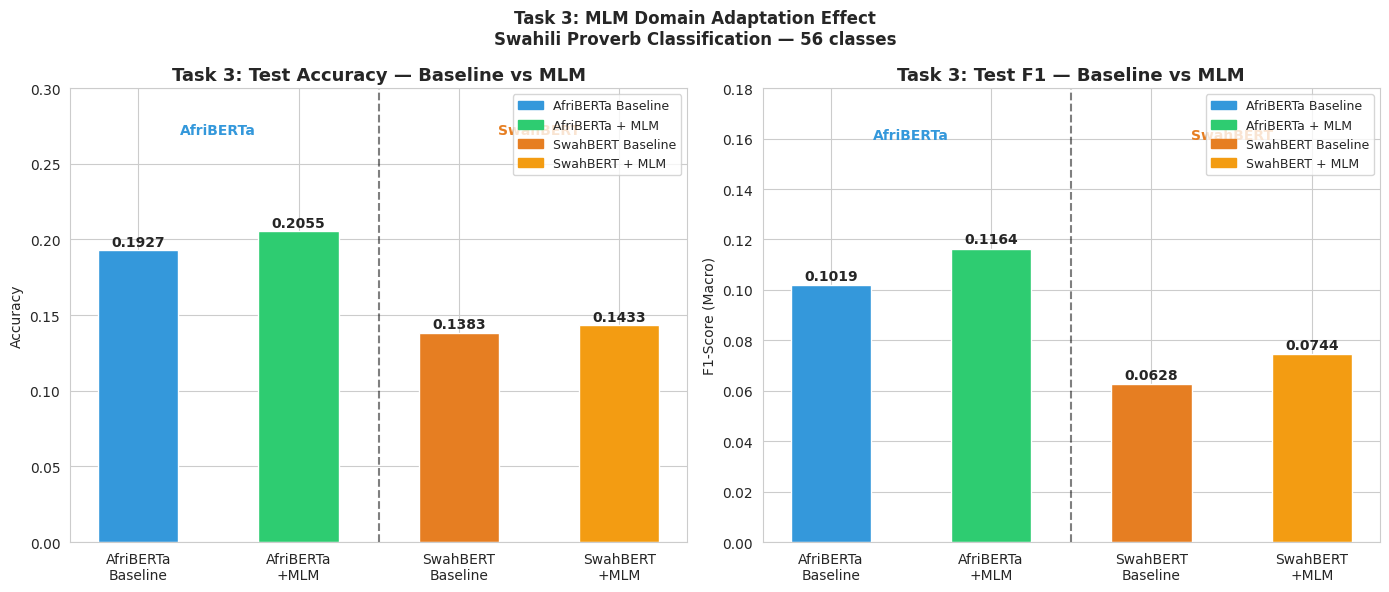


TASK 3 KEY FINDINGS
AfriBERTa MLM improvement (Acc): +1.28% | (F1): +1.45%
SwahBERT  MLM improvement (Acc): +0.49% | (F1): +1.16%

Best model overall: AfriBERTa + MLM (Acc=0.2055, F1=0.1164)
MLM adaptation consistently improves both models

✓ Task 3 results saved!


In [14]:
# Full Task 3 comparison
task3_results = pd.DataFrame([
    {'Model': 'AfriBERTa\nBaseline',  'Type': 'Baseline', 'Test Acc': 0.1927, 'Test F1': 0.1019},
    {'Model': 'AfriBERTa\n+MLM',      'Type': '+MLM',     'Test Acc': 0.2055, 'Test F1': 0.1164},
    {'Model': 'SwahBERT\nBaseline',   'Type': 'Baseline', 'Test Acc': 0.1383, 'Test F1': 0.0628},
    {'Model': 'SwahBERT\n+MLM',       'Type': '+MLM',     'Test Acc': 0.1433, 'Test F1': 0.0744},
])

colors = ['#3498db', '#2ecc71', '#e67e22', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(task3_results['Model'], task3_results['Test Acc'],
                    color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Task 3: Test Accuracy — Baseline vs MLM', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 0.30)
axes[0].axvline(x=1.5, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[0].text(0.5, 0.27, 'AfriBERTa', ha='center', fontsize=10, color='#3498db', fontweight='bold')
axes[0].text(2.5, 0.27, 'SwahBERT',  ha='center', fontsize=10, color='#e67e22', fontweight='bold')
for bar, val in zip(bars1, task3_results['Test Acc']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.003,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(task3_results['Model'], task3_results['Test F1'],
                    color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Task 3: Test F1 — Baseline vs MLM', fontweight='bold', fontsize=13)
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_ylim(0, 0.18)
axes[1].axvline(x=1.5, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1].text(0.5, 0.16, 'AfriBERTa', ha='center', fontsize=10, color='#3498db', fontweight='bold')
axes[1].text(2.5, 0.16, 'SwahBERT',  ha='center', fontsize=10, color='#e67e22', fontweight='bold')
for bar, val in zip(bars2, task3_results['Test F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#3498db', label='AfriBERTa Baseline'),
    mpatches.Patch(color='#2ecc71', label='AfriBERTa + MLM'),
    mpatches.Patch(color='#e67e22', label='SwahBERT Baseline'),
    mpatches.Patch(color='#f39c12', label='SwahBERT + MLM'),
]
axes[0].legend(handles=legend_elements, fontsize=9)
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Task 3: MLM Domain Adaptation Effect\nSwahili Proverb Classification — 56 classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('TASK 3 KEY FINDINGS')
print('='*60)
print(f'AfriBERTa MLM improvement (Acc): +1.28% | (F1): +1.45%')
print(f'SwahBERT  MLM improvement (Acc): +0.49% | (F1): +1.16%')
print(f'\nBest model overall: AfriBERTa + MLM (Acc=0.2055, F1=0.1164)')
print(f'MLM adaptation consistently improves both models')

task3_results.to_csv('/tmp/task3_results.csv', index=False)
print('\n✓ Task 3 results saved!')